In [1]:
import pickle, numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (f1_score, roc_auc_score,
    average_precision_score, classification_report)
import matplotlib.pyplot as plt

# Must define Autoencoder before unpickling (notebook 03 stored the model object)
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 8),         nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),         nn.ReLU(),
            nn.Linear(32, 64),        nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

with open('../preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_raw = data['X_train_normal'].values.astype(np.float32)
X_test_raw  = data['X_test'].values.astype(np.float32)
y_test      = data['y_test']
IN_DIM      = X_train_raw.shape[1]
device      = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device} | Input dim: {IN_DIM}')

Using device: cpu | Input dim: 16


In [2]:
SEQ_LEN  = 4
PAD      = (SEQ_LEN - IN_DIM % SEQ_LEN) % SEQ_LEN
FEAT_DIM = IN_DIM + PAD
STEP_DIM = FEAT_DIM // SEQ_LEN

def to_seq(X):
    if PAD > 0:
        X = np.hstack([X, np.zeros((len(X), PAD), dtype=np.float32)])
    return X.reshape(len(X), SEQ_LEN, STEP_DIM)

X_train_seq = to_seq(X_train_raw)
X_test_seq  = to_seq(X_test_raw)
print(f'Sequence shape: {X_train_seq.shape}  (samples, steps={SEQ_LEN}, feat={STEP_DIM})')

Sequence shape: (6358, 4, 4)  (samples, steps=4, feat=4)


In [3]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, step_dim, seq_len, hidden=64, latent=16):
        super().__init__()
        self.seq_len  = seq_len
        self.enc_lstm = nn.LSTM(step_dim, hidden, batch_first=True,
                                 num_layers=2, dropout=0.1)
        self.enc_fc   = nn.Linear(hidden, latent)
        self.dec_fc   = nn.Linear(latent, hidden)
        self.dec_lstm = nn.LSTM(hidden, hidden, batch_first=True,
                                 num_layers=2, dropout=0.1)
        self.out_fc   = nn.Linear(hidden, step_dim)

    def forward(self, x):
        _, (h, _) = self.enc_lstm(x)
        z         = self.enc_fc(h[-1])
        z_seq     = self.dec_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        dec, _    = self.dec_lstm(z_seq)
        return self.out_fc(dec)

lstm_ae = LSTMAutoencoder(STEP_DIM, SEQ_LEN).to(device)
print(f'LSTM-AE parameters: {sum(p.numel() for p in lstm_ae.parameters()):,}')

LSTM-AE parameters: 120,148


Training LSTM-AE on Normal data only...


  Epoch  25/100  Loss: 0.076761  LR: 0.00100


  Epoch  50/100  Loss: 0.024910  LR: 0.00050


  Epoch  75/100  Loss: 0.019502  LR: 0.00025


  Epoch 100/100  Loss: 0.017791  LR: 0.00013


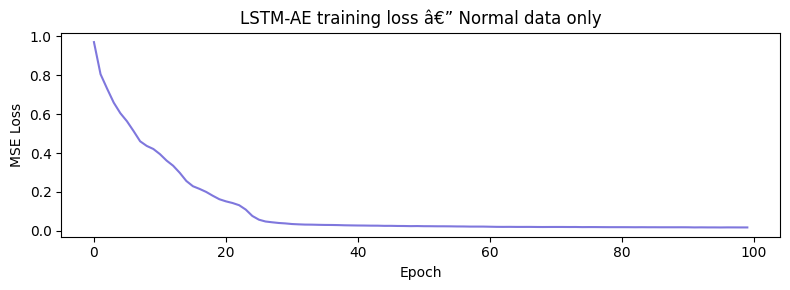

In [4]:
Xt     = torch.FloatTensor(X_train_seq).to(device)
loader = DataLoader(TensorDataset(Xt, Xt), batch_size=128, shuffle=True)
opt    = torch.optim.Adam(lstm_ae.parameters(), lr=1e-3)
sched  = torch.optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.5)
loss_fn= nn.MSELoss()

print('Training LSTM-AE on Normal data only...')
losses = []
for epoch in range(100):
    lstm_ae.train()
    ep = 0
    for xb, _ in loader:
        recon = lstm_ae(xb)
        loss  = loss_fn(recon, xb)
        opt.zero_grad(); loss.backward(); opt.step()
        ep += loss.item()
    sched.step()
    losses.append(ep / len(loader))
    if (epoch+1) % 25 == 0:
        print(f'  Epoch {epoch+1:>3}/100  Loss: {losses[-1]:.6f}  LR: {sched.get_last_lr()[0]:.5f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, color='#7F77DD')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('LSTM-AE training loss â€” Normal data only')
plt.tight_layout()
plt.savefig('../outputs/lstmae_loss.png', dpi=150)
plt.show()

In [5]:
def seq_errors(model, X_seq):
    model.eval()
    with torch.no_grad():
        Xt = torch.FloatTensor(X_seq).to(device)
        r  = model(Xt)
        return ((Xt - r)**2).mean(dim=(1, 2)).cpu().numpy()

train_err  = seq_errors(lstm_ae, X_train_seq)
test_err   = seq_errors(lstm_ae, X_test_seq)
threshold  = np.percentile(train_err, 95)
lstm_preds = (test_err > threshold).astype(int)

print(f'\nThreshold: {threshold:.6f}')
print('\n=== LSTM Autoencoder Results ===')
print(classification_report(y_test, lstm_preds,
      target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC: {roc_auc_score(y_test, test_err):.4f}')
print(f'AUC-PR:  {average_precision_score(y_test, test_err):.4f}')


Threshold: 0.007978

=== LSTM Autoencoder Results ===
              precision    recall  f1-score   support

      Normal     0.4377    0.9321    0.5957      1590
     Anomaly     0.5781    0.0721    0.1282      2052

    accuracy                         0.4476      3642
   macro avg     0.5079    0.5021    0.3620      3642
weighted avg     0.5168    0.4476    0.3323      3642

AUC-ROC: 0.5063
AUC-PR:  0.5709


In [6]:
print('\n' + '='*60)
print('ALL MODELS COMPARISON â€” Original test set')
print('='*60)
print(f"{' Model':<22} {'F1':>8} {'AUC-ROC':>10} {'AUC-PR':>9}")
print('-'*52)
for name, preds, scores in [
    ('Isolation Forest',   data['iso_preds'],   data['iso_scores']),
    ('One-Class SVM',      data['ocsvm_preds'], data['ocsvm_scores']),
    ('Autoencoder',        data['ae_preds'],    data['ae_scores']),
    ('LSTM-AE (proposed)', lstm_preds,          test_err),
]:
    print(f'{name:<22} {f1_score(y_test,preds):>8.4f}'
          f' {roc_auc_score(y_test,scores):>10.4f}'
          f' {average_precision_score(y_test,scores):>9.4f}')


ALL MODELS COMPARISON â€” Original test set
 Model                       F1    AUC-ROC    AUC-PR
----------------------------------------------------
Isolation Forest         0.1067     0.5069    0.5697
One-Class SVM            0.1201     0.5124    0.5758
Autoencoder              0.1231     0.5144    0.5707
LSTM-AE (proposed)       0.1282     0.5063    0.5709


In [7]:
data['lstm_ae_model']  = lstm_ae
data['lstm_ae_scores'] = test_err
data['lstm_ae_preds']  = lstm_preds
data['lstm_ae_thresh'] = threshold
data['SEQ_LEN']        = SEQ_LEN
data['STEP_DIM']       = STEP_DIM
data['PAD']            = PAD
with open('../preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print('\nSaved. Run notebook 5 next.')


Saved. Run notebook 5 next.
